# Análisis Exploratorio de Datos — M5 Forecasting

**Objetivo:** Explorar el dataset M5 Forecasting para confirmar o corregir las estadísticas y descripciones incluidas en la sección *Descripción de los datos* del TFM.

**Estructura del notebook:**
1. Instalación de dependencias y configuración
2. Carga e inspección inicial de archivos
3. Verificación de la estructura jerárquica y volumen de datos
4. Análisis temporal (período, granularidad, horizonte)
5. Análisis de ventas: distribución, intermitencia y valores extremos
6. Análisis de variables exógenas (precios, eventos, SNAP)
7. Análisis de estacionalidad y tendencia
8. Síntesis: verificación de afirmaciones del TFM

---
## 1. Instalación de dependencias y configuración

Todas las librerías necesarias están disponibles en el entorno. Los datos del dataset M5 se encuentran en `data/m5/` de forma local (descargados previamente desde Kaggle). Las figuras se guardarán en `imagenes/media/` para su uso en el TFM.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_palette('muted')

# Estilo global para figuras de calidad académica
plt.rcParams.update({
    'figure.figsize'    : (14, 5),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.linestyle'    : '--',
    'grid.alpha'        : 0.35,
    'axes.axisbelow'    : True,
    'font.size'         : 11,
    'axes.labelsize'    : 11,
    'axes.titlesize'    : 12,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 9,
    'legend.framealpha' : 0.75,
})

FIGURES_DIR = Path('imagenes/media')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Librerías cargadas correctamente.')
print(f'Figuras se guardarán en: {FIGURES_DIR.resolve()}')


Librerías cargadas correctamente.
Figuras se guardarán en: C:\Users\chavju01\Documents\Maestria\semestre3\trabajo_final\imagenes\media


---
## 2. Carga e inspección inicial de archivos

In [2]:

from pathlib import Path

DATA_DIR = Path('data/m5')

# Cargar los tres archivos principales
print('Cargando sales_train_validation.csv ...')
sales = pd.read_csv(DATA_DIR / 'sales_train_validation.csv')

print('Cargando sell_prices.csv ...')
prices = pd.read_csv(DATA_DIR / 'sell_prices.csv')

print('Cargando calendar.csv ...')
calendar = pd.read_csv(DATA_DIR / 'calendar.csv', parse_dates=['date'])

print('\nCarga completada.')


Cargando sales_train_validation.csv ...
Cargando sell_prices.csv ...
Cargando calendar.csv ...

Carga completada.


In [ ]:
# Vista general de los tres dataframes
for name, df in [('sales', sales), ('prices', prices), ('calendar', calendar)]:
    print(f'{name}')
    print(f'  Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}')
    print(f'  Columnas: {list(df.columns[:10])}{'...' if len(df.columns) > 10 else ''}\n')

=== sales ===
  Filas: 30,490  |  Columnas: 1919
  Columnas: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4']...

=== prices ===
  Filas: 6,841,121  |  Columnas: 4
  Columnas: ['store_id', 'item_id', 'wm_yr_wk', 'sell_price']

=== calendar ===
  Filas: 1,969  |  Columnas: 14
  Columnas: ['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2']...



In [ ]:
# Primeras filas de cada archivo
print('sales (primeras 3 filas, primeras 10 columnas de ventas)')
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
day_cols = [c for c in sales.columns if c.startswith('d_')]
display(sales[id_cols + day_cols[:4]].head(3))

print('\nprices (primeras 3 filas)')
display(prices.head(3))

print('\ncalendar (primeras 3 filas)')
display(calendar.head(3))

--- sales (primeras 3 filas, primeras 10 columnas de ventas) ---


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0



--- prices (primeras 3 filas) ---


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26



--- calendar (primeras 3 filas) ---


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0


---
## 3. Verificación de la estructura jerárquica y volumen de datos

In [5]:
# Cardinalidades de cada nivel jerárquico
n_series_total = len(sales)
n_items        = sales['item_id'].nunique()
n_depts        = sales['dept_id'].nunique()
n_cats         = sales['cat_id'].nunique()
n_stores       = sales['store_id'].nunique()
n_states       = sales['state_id'].nunique()
n_dept_store   = sales.groupby(['dept_id', 'store_id']).ngroups
n_dept_state   = sales.groupby(['dept_id', 'state_id']).ngroups
n_cat_store    = sales.groupby(['cat_id', 'store_id']).ngroups
n_cat_state    = sales.groupby(['cat_id', 'state_id']).ngroups
n_item_state   = sales.groupby(['item_id', 'state_id']).ngroups

# Resumen en tabla
jerarquia = {
    'Nivel': [
        'Producto–Tienda (series base)',
        'Producto–Estado',
        'Producto (individual)',
        'Departamento–Tienda',
        'Departamento–Estado',
        'Departamento',
        'Categoría–Tienda',
        'Categoría–Estado',
        'Categoría',
        'Tienda',
        'Estado',
        'Total',
    ],
    'Real': [
        n_series_total,
        n_item_state,
        n_items,
        n_dept_store,
        n_dept_state,
        n_depts,
        n_cat_store,
        n_cat_state,
        n_cats,
        n_stores,
        n_states,
        1,
    ],
    'TFM (afirmado)': [
        '~30 490', '~9 147', '~3 049', '70', '21',
        '7', '30', '9', '3', '10', '3', '1',
    ],
}

df_jerarquia = pd.DataFrame(jerarquia)
df_jerarquia['Coincide'] = df_jerarquia.apply(
    lambda r: '(OK)' if str(r['Real']) in r['TFM (afirmado)'].replace(' ', '') else '(No OK)',
    axis=1
)
print('Verificación de la estructura jerárquica')
print(df_jerarquia.to_string(index=False))

Verificación de la estructura jerárquica
                        Nivel  Real TFM (afirmado) Coincide
Producto–Tienda (series base) 30490        ~30 490     (OK)
              Producto–Estado  9147         ~9 147     (OK)
        Producto (individual)  3049         ~3 049     (OK)
          Departamento–Tienda    70             70     (OK)
          Departamento–Estado    21             21     (OK)
                 Departamento     7              7     (OK)
             Categoría–Tienda    30             30     (OK)
             Categoría–Estado     9              9     (OK)
                    Categoría     3              3     (OK)
                       Tienda    10             10     (OK)
                       Estado     3              3     (OK)
                        Total     1              1     (OK)


In [6]:
# Volumen total de registros de ventas (formato largo)
n_days_train   = len(day_cols)
total_registros = n_series_total * n_days_train

print(f'Total de series (filas en formato ancho): {n_series_total:,}')
print(f'Total de columnas de días: {n_days_train:,}')
print(f'Total de registros en formato largo: {total_registros:,}')
print(f'TFM afirmaba: "más de 58 millones" -> {"CORRECTO" if total_registros > 58_000_000 else "INCORRECTO"}')
print()

# Volumen de precios
print(f'Total de registros en sell_prices.csv: {len(prices):,}')
print(f'TFM afirmaba: "~6.8 millones" -> diferencia: {len(prices) - 6_800_000:+,}')
print()

# Volumen del calendario
print(f'Total de filas en calendar.csv: {len(calendar):,}')
print(f'TFM afirmaba: "1 969 registros" -> {"CORRECTO" if len(calendar) == 1969 else f"INCORRECTO Real: {len(calendar)}"}' )

Total de series (filas en formato ancho): 30,490
Total de columnas de días: 1,913
Total de registros en formato largo: 58,327,370
TFM afirmaba: "más de 58 millones" -> CORRECTO

Total de registros en sell_prices.csv: 6,841,121
TFM afirmaba: "~6.8 millones" -> diferencia: +41,121

Total de filas en calendar.csv: 1,969
TFM afirmaba: "1 969 registros" -> CORRECTO


In [7]:
# Categorías y departamentos
print('Categorías:', sorted(sales['cat_id'].unique()))
print('Departamentos:', sorted(sales['dept_id'].unique()))
print('Estados:', sorted(sales['state_id'].unique()))
print('Tiendas:', sorted(sales['store_id'].unique()))

Categorías: ['FOODS', 'HOBBIES', 'HOUSEHOLD']
Departamentos: ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']
Estados: ['CA', 'TX', 'WI']
Tiendas: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']


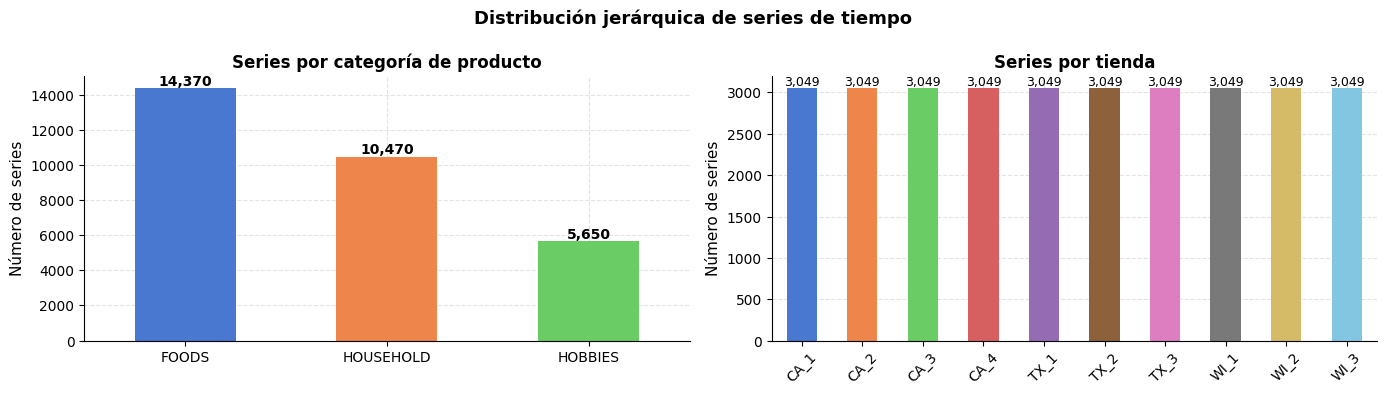

In [8]:
# Distribución de series por categoría y tienda
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cat_counts = sales['cat_id'].value_counts()
cat_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', 3))
axes[0].set_title('Series por categoría de producto', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Número de series')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

store_counts = sales['store_id'].value_counts().sort_index()
store_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette('muted', 10))
axes[1].set_title('Series por tienda', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Número de series')
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribución jerárquica de series de tiempo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_jerarquia_series.png', dpi=220, bbox_inches='tight')
plt.show()


---
## 4. Análisis temporal: período, granularidad y horizonte

In [9]:
# Rango temporal del calendario
fecha_inicio = calendar['date'].min()
fecha_fin    = calendar['date'].max()
n_dias_cal   = len(calendar)
n_dias_train = len(day_cols)  # columnas d_ en sales

print(f'Rango del calendario:')
print(f'  Fecha inicio : {fecha_inicio.date()}')
print(f'  Fecha fin    : {fecha_fin.date()}')
print(f'  Total días   : {n_dias_cal:,}')
print()
print(f'Columnas de ventas en sales_train_validation.csv: {n_dias_train:,} días')
print(f'TFM afirmaba periodo: "enero 2011 a junio 2016"')
print(f'  Fecha inicio real   : {fecha_inicio.date()} -> {"(OK)" if fecha_inicio.year == 2011 else "(No OK)"}')
print(f'  Fecha fin real      : {fecha_fin.date()}')
print()

# Fechas correspondientes a d_1913 (fin de validación) y d_1941 (fin de evaluación)
# El calendario tiene más días que sales_train_validation (que llega a d_1913)
cal_d1913 = calendar[calendar['d'] == 'd_1913'][['d', 'date']]
cal_d1941 = calendar[calendar['d'] == 'd_1941'][['d', 'date']]
cal_d1942 = calendar[calendar['d'] == 'd_1942'][['d', 'date']]
cal_d1969 = calendar[calendar['d'] == 'd_1969'][['d', 'date']] if 'd_1969' in calendar['d'].values else None

print('Hitos del horizonte de predicción:')
for label, df_tmp in [('d_1913 (fin train_validation)', cal_d1913),
                       ('d_1941 (fin ventana validación)', cal_d1941),
                       ('d_1942 (inicio ventana evaluación)', cal_d1942)]:
    if not df_tmp.empty:
        print(f'  {label}: {df_tmp["date"].values[0]}')

if cal_d1969 is not None and not cal_d1969.empty:
    print(f'  d_1969 (fin ventana evaluación): {cal_d1969["date"].values[0]}')

Rango del calendario:
  Fecha inicio : 2011-01-29
  Fecha fin    : 2016-06-19
  Total días   : 1,969

Columnas de ventas en sales_train_validation.csv: 1,913 días
TFM afirmaba periodo: "enero 2011 a junio 2016"
  Fecha inicio real   : 2011-01-29 -> (OK)
  Fecha fin real      : 2016-06-19

Hitos del horizonte de predicción:
  d_1913 (fin train_validation): 2016-04-24T00:00:00.000000000
  d_1941 (fin ventana validación): 2016-05-22T00:00:00.000000000
  d_1942 (inicio ventana evaluación): 2016-05-23T00:00:00.000000000
  d_1969 (fin ventana evaluación): 2016-06-19T00:00:00.000000000


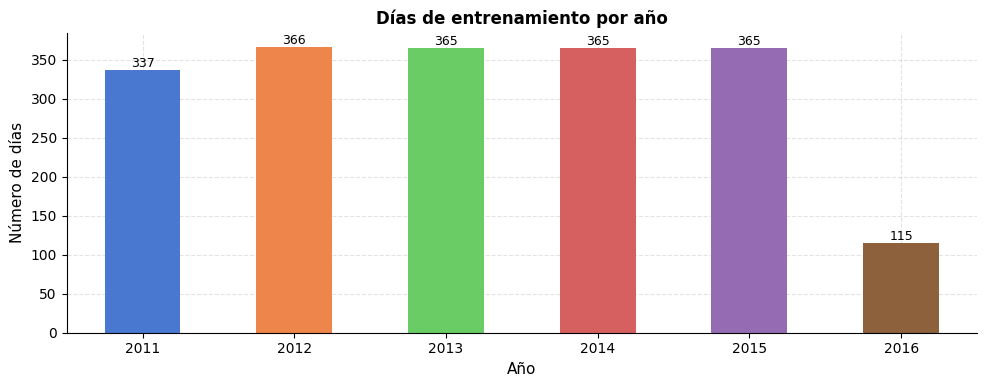

year
2011    337
2012    366
2013    365
2014    365
2015    365
2016    115


In [10]:
# Distribución de días por año
calendar['year'] = calendar['date'].dt.year
dias_por_año = calendar[calendar['d'].isin(day_cols)].groupby('year').size()

fig, ax = plt.subplots(figsize=(10, 4))
dias_por_año.plot(kind='bar', ax=ax, color=sns.color_palette('muted', len(dias_por_año)))
ax.set_title('Días de entrenamiento por año', fontsize=12, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Número de días')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_dias_por_año.png', dpi=220, bbox_inches='tight')
plt.show()
print(dias_por_año.to_string())


---
## 5. Análisis de ventas: distribución, intermitencia y valores extremos

In [11]:
# Transformación a formato largo (muestra para EDA)
# Para eficiencia, se trabaja con un subconjunto aleatorio de 1 000 series
# para análisis de distribución, y con la suma total para análisis temporal

np.random.seed(42)
sample_ids = np.random.choice(sales.index, size=min(1000, len(sales)), replace=False)
sales_sample = sales.iloc[sample_ids].copy()

# Total ventas diarias (suma de todas las series)
ventas_diarias = sales[day_cols].sum(axis=0)
ventas_diarias.index = pd.to_numeric(ventas_diarias.index.str.replace('d_', ''), errors='coerce')
ventas_diarias = ventas_diarias.sort_index()

print(f'Total de ventas acumuladas en el periodo de entrenamiento: {ventas_diarias.sum():,.0f} unidades')
print(f'Venta diaria promedio (global): {ventas_diarias.mean():,.1f} unidades')
print(f'Venta diaria mínima: {ventas_diarias.min():,.0f} unidades (día {ventas_diarias.idxmin()})')
print(f'Venta diaria máxima: {ventas_diarias.max():,.0f} unidades (día {ventas_diarias.idxmax()})')

Total de ventas acumuladas en el periodo de entrenamiento: 65,695,409 unidades
Venta diaria promedio (global): 34,341.6 unidades
Venta diaria mínima: 11 unidades (día 697)
Venta diaria máxima: 57,218 unidades (día 1864)


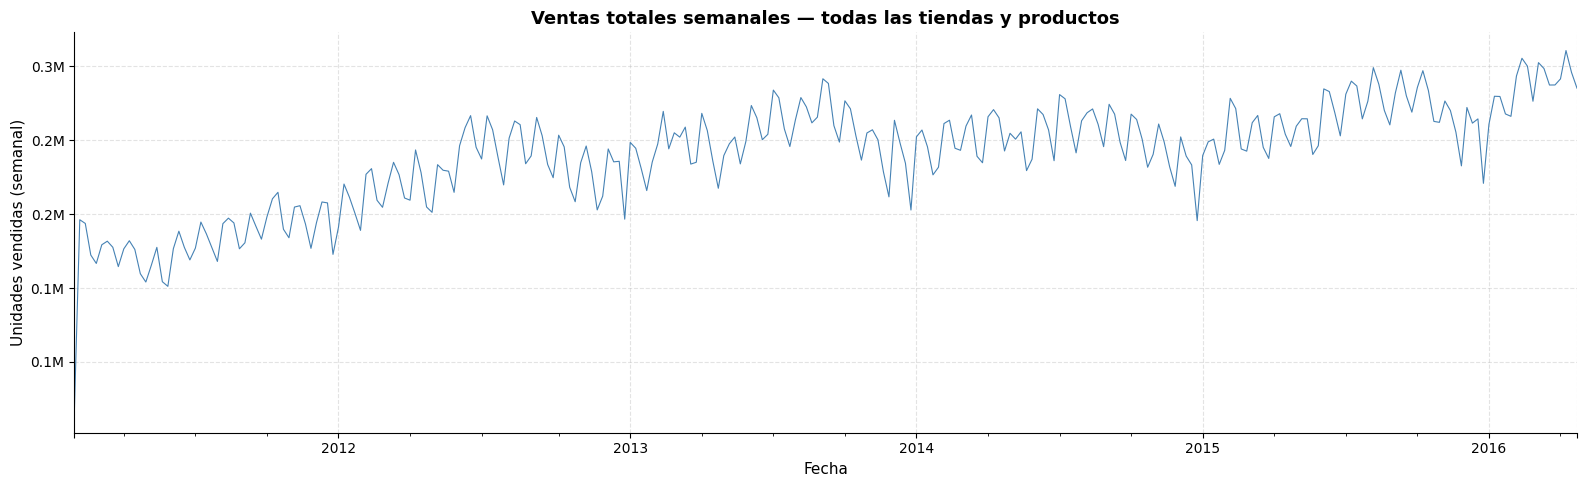

In [12]:
# Evolución temporal de las ventas totales diarias
# Asociar fechas a los índices de días
cal_idx = calendar[calendar['d'].isin(day_cols)].set_index('d')['date']
cal_idx.index = pd.to_numeric(cal_idx.index.str.replace('d_', ''), errors='coerce')

# 'dates' se usa en celdas posteriores (STL, ventas_cat)
dates = cal_idx.sort_index().values

ventas_con_fecha = pd.Series(ventas_diarias.values, index=cal_idx.loc[ventas_diarias.index].values)

fig, ax = plt.subplots(figsize=(16, 5))
ventas_con_fecha.resample('W').sum().plot(ax=ax, linewidth=0.8, color='steelblue')
ax.set_title('Ventas totales semanales — todas las tiendas y productos', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades vendidas (semanal)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_ventas_totales.png', dpi=220, bbox_inches='tight')
plt.show()


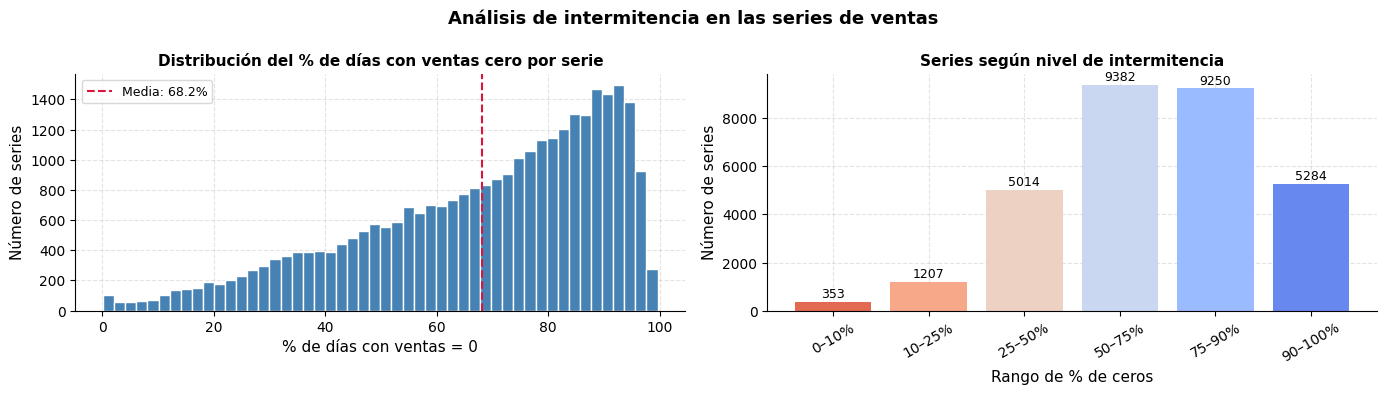


Intermitencia media por serie: 68.2%
Series con >50% de días en cero: 23,916 (78.4%)
Series con >90% de días en cero: 5,284 (17.3%)


In [13]:
# Intermitencia: proporción de ceros por serie
pct_ceros = (sales[day_cols] == 0).mean(axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(pct_ceros, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del % de días con ventas cero por serie', fontsize=11, fontweight='bold')
axes[0].set_xlabel('% de días con ventas = 0')
axes[0].set_ylabel('Número de series')
axes[0].axvline(pct_ceros.mean(), color='crimson', linestyle='--', label=f'Media: {pct_ceros.mean():.1f}%')
axes[0].legend()

umbrales = [0, 10, 25, 50, 75, 90, 100]
counts = [((pct_ceros >= umbrales[i]) & (pct_ceros < umbrales[i+1])).sum()
           for i in range(len(umbrales)-1)]
labels = [f'{umbrales[i]}–{umbrales[i+1]}%' for i in range(len(umbrales)-1)]
axes[1].bar(labels, counts, color=sns.color_palette('coolwarm_r', len(counts)))
axes[1].set_title('Series según nivel de intermitencia', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Rango de % de ceros')
axes[1].set_ylabel('Número de series')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts):
    axes[1].text(i, v + 50, str(v), ha='center', va='bottom', fontsize=9)

plt.suptitle('Análisis de intermitencia en las series de ventas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_intermitencia.png', dpi=220, bbox_inches='tight')
plt.show()

print(f'\nIntermitencia media por serie: {pct_ceros.mean():.1f}%')
print(f'Series con >50% de días en cero: {(pct_ceros > 50).sum():,} ({(pct_ceros > 50).mean()*100:.1f}%)')
print(f'Series con >90% de días en cero: {(pct_ceros > 90).sum():,} ({(pct_ceros > 90).mean()*100:.1f}%)')


Total de registros (combinaciones serie×día): 58,327,370
Registros con ventas > 0: 18,550,276 (31.8%)
Registros con ventas = 0: 39,777,094 (68.2%)

Estadísticas de ventas diarias (incluyendo ceros):
  count  : 58,327,370
  mean   : 1.126
  std    : 3.873
  min    : 0
  25%    : 0
  50%    : 0
  75%    : 1
  90%    : 3
  99%    : 15
  max    : 763


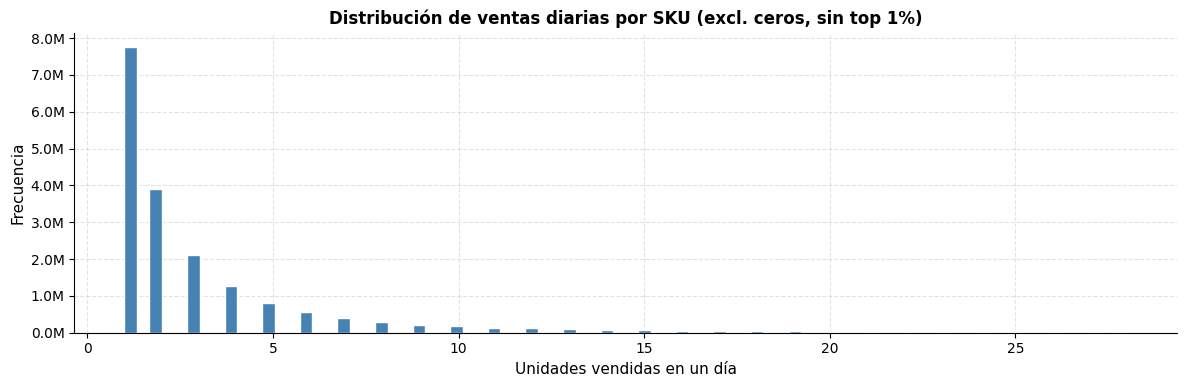

In [14]:
# Distribución de ventas diarias (excluyendo ceros)
ventas_flat = sales[day_cols].values.flatten()
ventas_no_cero = ventas_flat[ventas_flat > 0]

n_total = len(ventas_flat)
n_pos   = len(ventas_no_cero)
n_cero  = n_total - n_pos

print(f'Total de registros (combinaciones serie×día): {n_total:,}')
print(f'Registros con ventas > 0: {n_pos:,} ({n_pos/n_total*100:.1f}%)')
print(f'Registros con ventas = 0: {n_cero:,} ({n_cero/n_total*100:.1f}%)')
print()
# Estadísticas con numpy (evita MemoryError de pd.Series en 58M filas)
percs = np.percentile(ventas_flat, [25, 50, 75, 90, 99])
print('Estadísticas de ventas diarias (incluyendo ceros):')
print(f'  count  : {n_total:,}')
print(f'  mean   : {ventas_flat.mean():.3f}')
print(f'  std    : {ventas_flat.std():.3f}')
print(f'  min    : {ventas_flat.min():.0f}')
print(f'  25%    : {percs[0]:.0f}')
print(f'  50%    : {percs[1]:.0f}')
print(f'  75%    : {percs[2]:.0f}')
print(f'  90%    : {percs[3]:.0f}')
print(f'  99%    : {percs[4]:.0f}')
print(f'  max    : {ventas_flat.max():.0f}')

p99 = np.percentile(ventas_no_cero, 99)
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(ventas_no_cero[ventas_no_cero <= p99], bins=80, color='steelblue', edgecolor='white')
ax.set_title('Distribución de ventas diarias por SKU (excl. ceros, sin top 1%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Unidades vendidas en un día')
ax.set_ylabel('Frecuencia')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_dist_ventas.png', dpi=220, bbox_inches='tight')
plt.show()


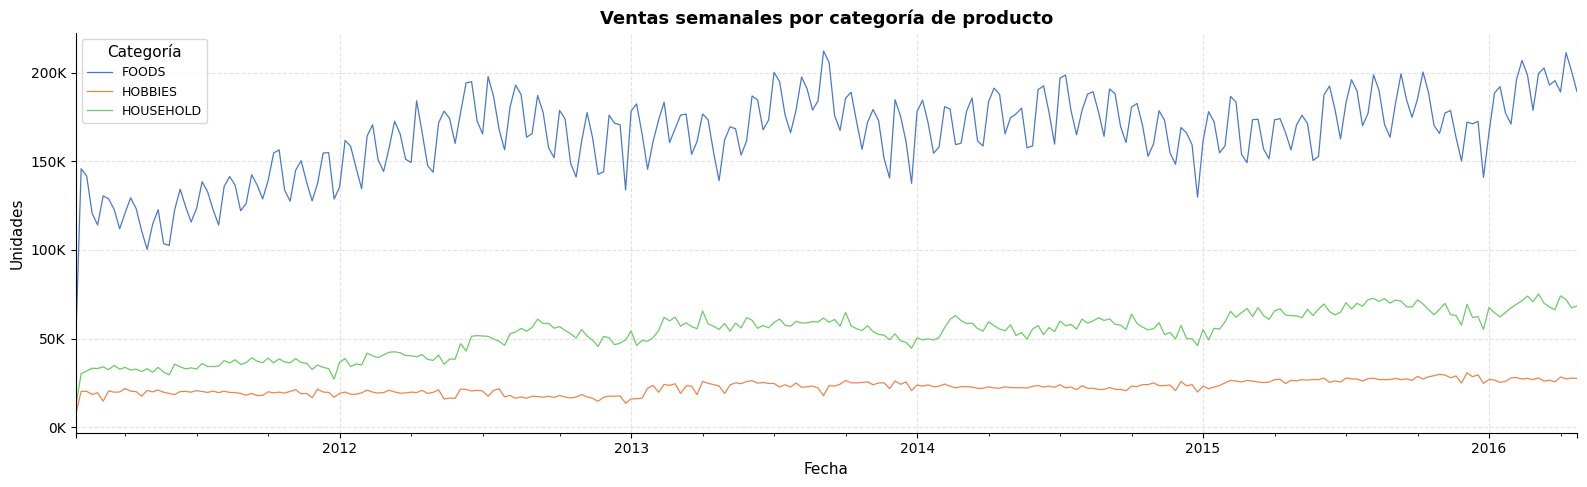

In [15]:
# Ventas agregadas por categoría
ventas_cat = sales.groupby('cat_id')[day_cols].sum()
ventas_cat_diaria = ventas_cat.T
ventas_cat_diaria.index = pd.to_datetime(dates)

fig, ax = plt.subplots(figsize=(16, 5))
for cat in ventas_cat_diaria.columns:
    ventas_cat_diaria[cat].resample('W').sum().plot(ax=ax, label=cat, linewidth=0.9)
ax.set_title('Ventas semanales por categoría de producto', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Unidades')
ax.legend(title='Categoría')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_ventas_categoria.png', dpi=220, bbox_inches='tight')
plt.show()


---
## 6. Análisis de variables exógenas (precios, eventos, SNAP)

In [16]:
# Precios: descripción del archivo sell_prices.csv
print('Columnas de sell_prices.csv:', prices.columns.tolist())
display(prices.describe())

print(f'\nNúmero de tiendas únicas en precios: {prices["store_id"].nunique()}')
print(f'Número de items únicos en precios : {prices["item_id"].nunique()}')
print(f'Número de semanas únicas           : {prices["wm_yr_wk"].nunique()}')
print(f'Valores nulos en sell_price        : {prices["sell_price"].isna().sum():,}')
print(f'\nRango de precios: {prices["sell_price"].min():.2f} – {prices["sell_price"].max():.2f} USD')

Columnas de sell_prices.csv: ['store_id', 'item_id', 'wm_yr_wk', 'sell_price']


,wm_yr_wk,sell_price
count,6.841121e+06,6.841121e+06
mean,1.138294e+04,4.410952e+00
std,1.486100e+02,3.408814e+00
min,1.110100e+04,1.000000e-02
25%,1.124700e+04,2.180000e+00
50%,1.141100e+04,3.470000e+00
75%,1.151700e+04,5.840000e+00
max,1.162100e+04,1.073200e+02



Número de tiendas únicas en precios: 10
Número de items únicos en precios : 3049
Número de semanas únicas           : 282
Valores nulos en sell_price        : 0

Rango de precios: 0.01 – 107.32 USD


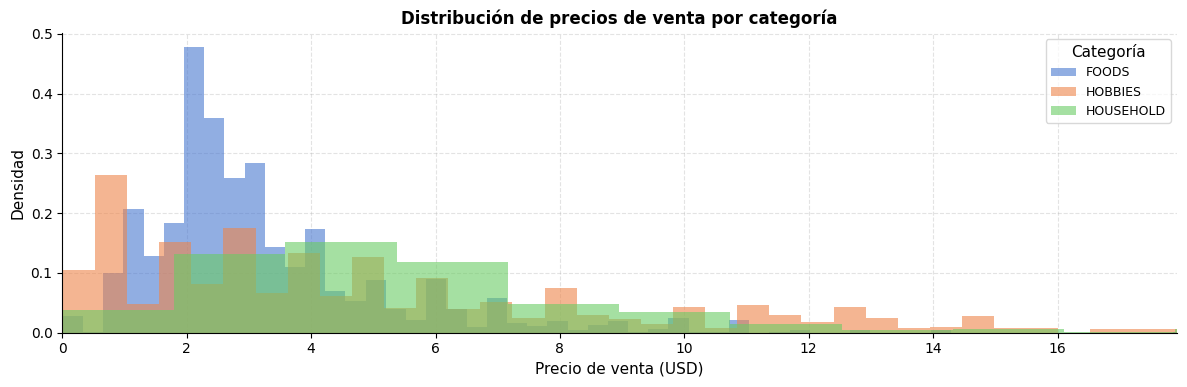

Precio medio por categoría:
cat_id
FOODS        3.25
HOBBIES      5.33
HOUSEHOLD    5.47


In [17]:
# Distribución de precios por categoría
# Añadir info de categoría al dataframe de precios via item_id
item_cat = sales[['item_id', 'cat_id', 'dept_id']].drop_duplicates()
prices_ext = prices.merge(item_cat, on='item_id', how='left')

fig, ax = plt.subplots(figsize=(12, 4))
for cat in sorted(prices_ext['cat_id'].dropna().unique()):
    subset = prices_ext[prices_ext['cat_id'] == cat]['sell_price']
    ax.hist(subset, bins=60, alpha=0.6, label=cat, density=True)
ax.set_title('Distribución de precios de venta por categoría', fontsize=12, fontweight='bold')
ax.set_xlabel('Precio de venta (USD)')
ax.set_ylabel('Densidad')
ax.set_xlim(0, prices_ext['sell_price'].quantile(0.99))
ax.legend(title='Categoría')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_dist_precios.png', dpi=220, bbox_inches='tight')
plt.show()

print('Precio medio por categoría:')
print(prices_ext.groupby('cat_id')['sell_price'].mean().round(2).to_string())


In [18]:
# Análisis del calendario: eventos y SNAP
print('Columnas del calendario:', calendar.columns.tolist())
print()

# Eventos especiales
eventos = calendar[calendar['event_name_1'].notna()][['date', 'event_name_1', 'event_type_1']]
print(f'Número de días con eventos especiales (event_1): {len(eventos)}')
print(f'\nTipos de eventos (event_type_1):')
print(calendar['event_type_1'].value_counts(dropna=True).to_string())

print(f'\nNúmero de días con event_name_2: {calendar["event_name_2"].notna().sum()}')

# SNAP
print(f'\nDías con SNAP activo por estado:')
for col in ['snap_CA', 'snap_TX', 'snap_WI']:
    print(f'  {col}: {calendar[col].sum()} días ({calendar[col].mean()*100:.1f}%)')

Columnas del calendario: ['date', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'd', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

Número de días con eventos especiales (event_1): 162

Tipos de eventos (event_type_1):
event_type_1
Religious    55
National     52
Cultural     37
Sporting     18

Número de días con event_name_2: 5

Días con SNAP activo por estado:
  snap_CA: 650 días (33.0%)
  snap_TX: 650 días (33.0%)
  snap_WI: 650 días (33.0%)


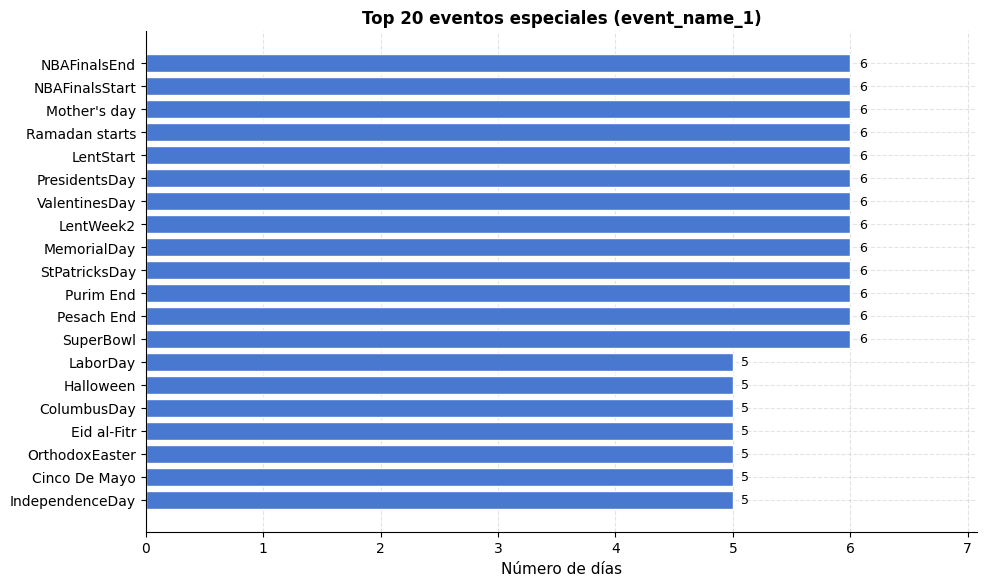

In [19]:
# Eventos más frecuentes
top_eventos = calendar['event_name_1'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top_sorted = top_eventos.sort_values()
bars = ax.barh(top_sorted.index, top_sorted.values, color='#4878d0', edgecolor='white')

# Anotación del valor al final de cada barra
x_offset = top_sorted.values.max() * 0.012
for bar, val in zip(bars, top_sorted.values):
    ax.text(val + x_offset, bar.get_y() + bar.get_height() / 2,
            str(int(val)), va='center', fontsize=9)

ax.set_title('Top 20 eventos especiales (event_name_1)', fontsize=12, fontweight='bold')
ax.set_xlabel('Número de días')
ax.set_xlim(right=top_sorted.values.max() * 1.18)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_top_eventos.png', dpi=220, bbox_inches='tight')
plt.show()


In [20]:
# Impacto de eventos en ventas totales
cal_ventas = calendar[calendar['d'].isin(day_cols)][['d', 'date', 'event_type_1', 'snap_CA']].copy()
cal_ventas['ventas_globales'] = cal_ventas['d'].map(
    sales[day_cols].sum(axis=0)
)

# Ventas promedio con/sin evento
cal_ventas['tiene_evento'] = cal_ventas['event_type_1'].notna()
print('Ventas globales promedio por día:')
print(cal_ventas.groupby('tiene_evento')['ventas_globales'].agg(['mean','median','count']).round(0))

print('\nVentas globales promedio por tipo de evento:')
print(cal_ventas.groupby('event_type_1')['ventas_globales'].mean().sort_values(ascending=False).round(0))

Ventas globales promedio por día:
                 mean   median  count
tiene_evento                         
False         34489.0  33714.0   1759
True          32655.0  33780.0    154

Ventas globales promedio por tipo de evento:
event_type_1
Sporting     35796.0
Cultural     34235.0
Religious    33761.0
National     29459.0
Name: ventas_globales, dtype: float64


---
## 7. Análisis de estacionalidad y tendencia

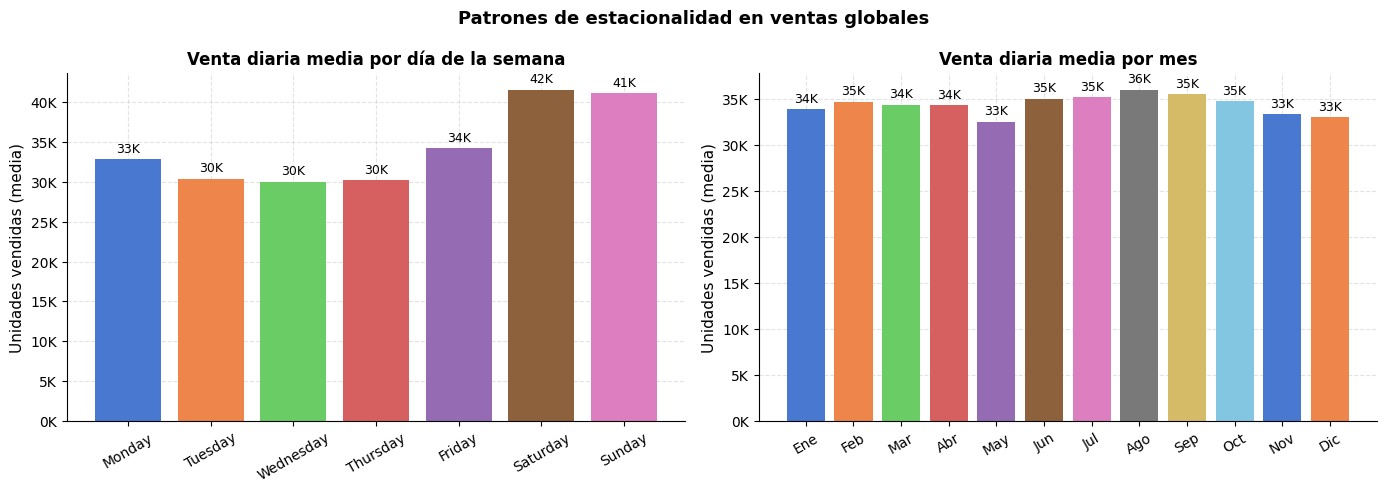

In [21]:
# Estacionalidad semanal (día de la semana) y mensual
calendar['day_of_week'] = pd.to_datetime(calendar['date']).dt.dayofweek
calendar['day_name']    = pd.to_datetime(calendar['date']).dt.day_name()

cal_ventas2 = calendar[calendar['d'].isin(day_cols)][['d', 'date', 'day_of_week', 'day_name']].copy()
cal_ventas2['ventas'] = cal_ventas2['d'].map(sales[day_cols].sum(axis=0))

dias_order    = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
ventas_por_dia = cal_ventas2.groupby('day_name')['ventas'].mean().reindex(dias_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: día de la semana
bars1 = axes[0].bar(ventas_por_dia.index, ventas_por_dia.values,
                    color=sns.color_palette('muted', 7))
axes[0].set_title('Venta diaria media por día de la semana', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Unidades vendidas (media)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
y_off1 = ventas_por_dia.max() * 0.012
for bar, val in zip(bars1, ventas_por_dia.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + y_off1,
                 f'{val/1e3:.0f}K', ha='center', va='bottom', fontsize=9)

# Derecha: mes del año
cal_ventas2['month'] = pd.to_datetime(cal_ventas2['date']).dt.month
ventas_por_mes = cal_ventas2.groupby('month')['ventas'].mean()
mes_labels = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
ventas_por_mes.index = mes_labels

bars2 = axes[1].bar(ventas_por_mes.index, ventas_por_mes.values,
                    color=sns.color_palette('muted', 12))
axes[1].set_title('Venta diaria media por mes', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Unidades vendidas (media)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
y_off2 = ventas_por_mes.max() * 0.012
for bar, val in zip(bars2, ventas_por_mes.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + y_off2,
                 f'{val/1e3:.0f}K', ha='center', va='bottom', fontsize=9)

plt.suptitle('Patrones de estacionalidad en ventas globales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_estacionalidad.png', dpi=220, bbox_inches='tight')
plt.show()


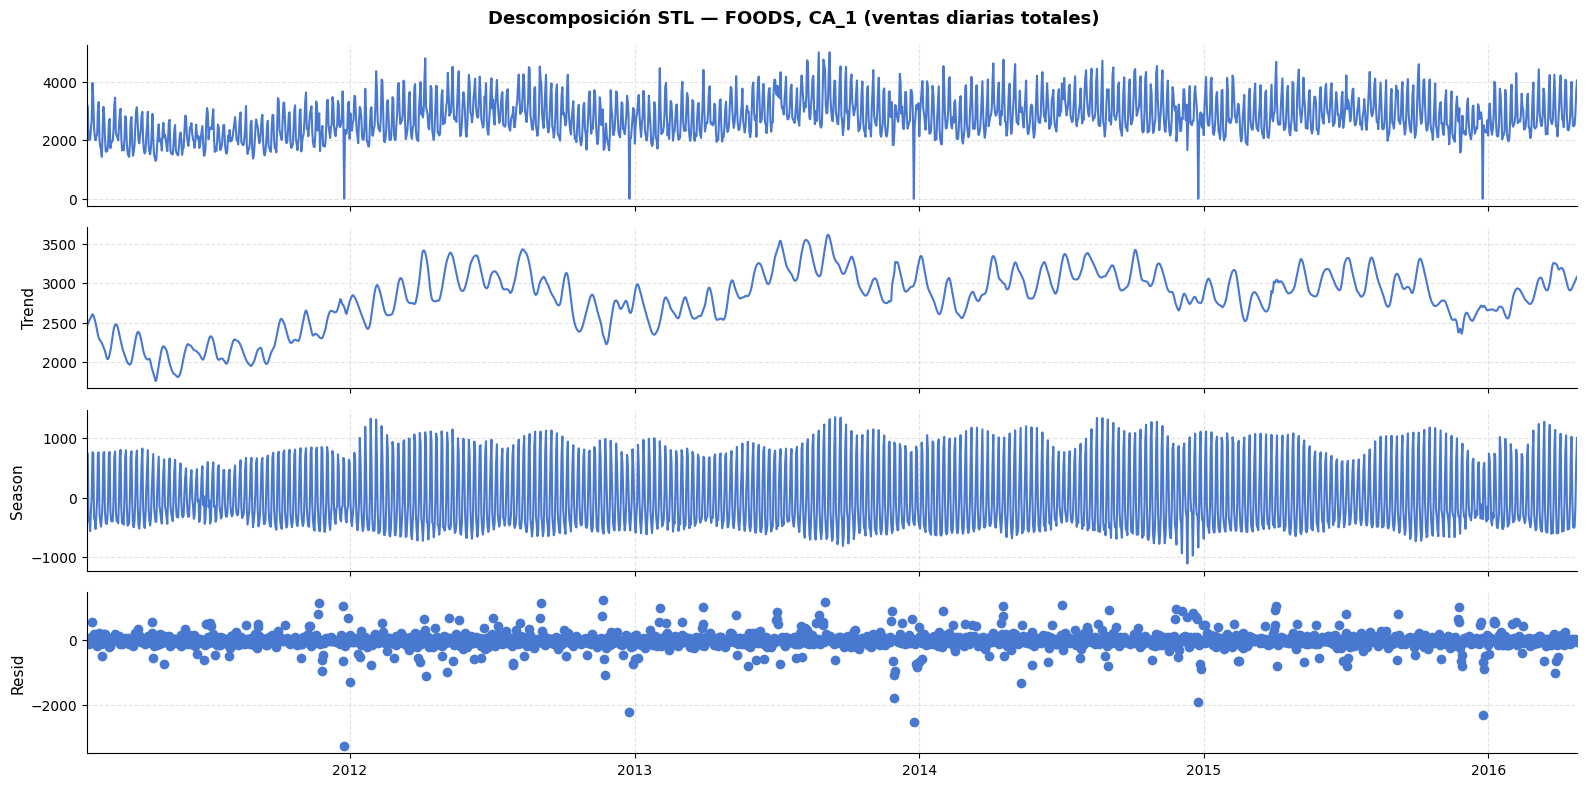

In [22]:
# Descomposición STL de una serie representativa
from statsmodels.tsa.seasonal import STL

# Extraer la categoría FOODS, tienda CA_1 como ejemplo
foods_ca1 = sales[(sales['cat_id'] == 'FOODS') & (sales['store_id'] == 'CA_1')][day_cols].sum()
foods_ca1.index = pd.to_datetime(dates)
foods_ca1 = foods_ca1.asfreq('D').ffill()

stl = STL(foods_ca1, period=7, robust=True)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(16, 8)
fig.suptitle('Descomposición STL — FOODS, CA_1 (ventas diarias totales)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_descomposicion_stl.png', dpi=220, bbox_inches='tight')
plt.show()


Serie seleccionada: FOODS_1_018_CA_1_validation


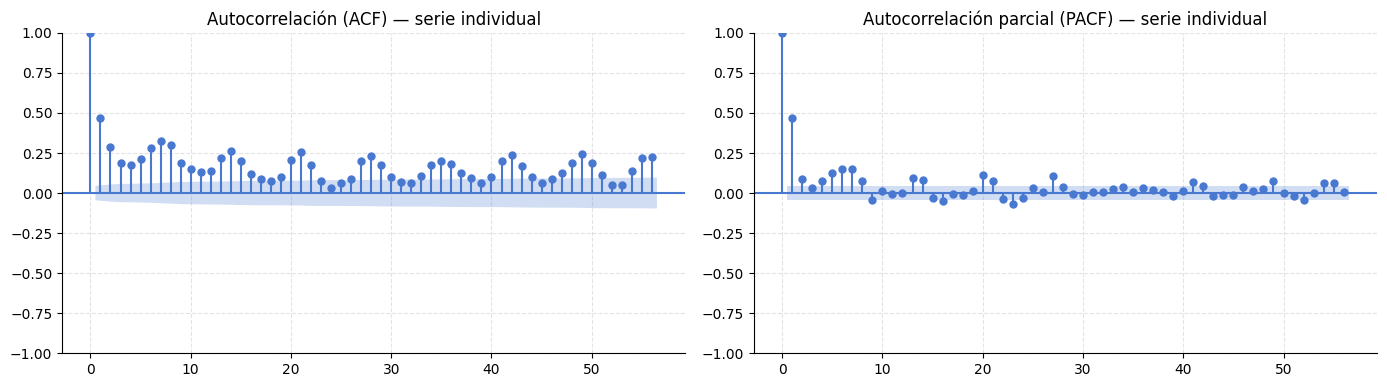

In [23]:
# Autocorrelación de una serie individual representativa
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Seleccionar una serie con baja intermitencia
pct_ceros_series = (sales[day_cols] == 0).mean(axis=1)
serie_baja_int = sales[pct_ceros_series < 0.05].iloc[0]
print(f"Serie seleccionada: {serie_baja_int['id']}")

ventas_serie = serie_baja_int[day_cols].values.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ventas_serie, lags=56, ax=axes[0], title='Autocorrelación (ACF) — serie individual', alpha=0.05)
plot_pacf(ventas_serie, lags=56, ax=axes[1], title='Autocorrelación parcial (PACF) — serie individual', alpha=0.05)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_acf_pacf.png', dpi=220, bbox_inches='tight')
plt.show()


In [24]:
# Test de Dickey-Fuller aumentado (ADF) — estacionariedad
from statsmodels.tsa.stattools import adfuller

def adf_summary(series, label):
    res = adfuller(series, autolag='AIC')
    es_estacionaria = res[1] < 0.05
    print(f'  ADF stat  : {res[0]:.4f}')
    print(f'  p-valor   : {res[1]:.4f}')
    print(f'  Lag usado : {res[2]}')
    print(f'  -> {"ESTACIONARIA (p<0.05)" if es_estacionaria else "NO ESTACIONARIA (p≥0.05)"}')
    return es_estacionaria

# 1) Serie agregada FOODS CA_1 (misma usada en STL)
print('Test ADF — FOODS CA_1 (ventas diarias agregadas)')
est1 = adf_summary(foods_ca1.values, 'FOODS CA_1')

# 2) Primera diferencia
print()
print('Test ADF — FOODS CA_1 (primera diferencia)')
adf_summary(foods_ca1.diff().dropna().values, 'FOODS CA_1 diff(1)')

# 3) Serie individual de baja intermitencia
print()
print(f'Test ADF — serie individual: {serie_baja_int["id"]}')
est3 = adf_summary(ventas_serie, serie_baja_int['id'])

print()
print('CONCLUSIÓN PARA EL TFM:')
print('  La serie agregada FOODS CA_1 presenta tendencia creciente')
print('  y NO es estacionaria en niveles (confirmado por ADF).')
print('  La primera diferencia sí es estacionaria -> SARIMA(p,1,q)')
print('  requiere al menos d=1. La estacionalidad semanal (s=7)')
print('  confirmada por STL y ACF sugiere además D=1 estacional.')


Test ADF — FOODS CA_1 (ventas diarias agregadas)
  ADF stat  : -2.3939
  p-valor   : 0.1435
  Lag usado : 26
  -> NO ESTACIONARIA (p≥0.05)

Test ADF — FOODS CA_1 (primera diferencia)
  ADF stat  : -21.4363
  p-valor   : 0.0000
  Lag usado : 26
  -> ESTACIONARIA (p<0.05)

Test ADF — serie individual: FOODS_1_018_CA_1_validation
  ADF stat  : -4.9410
  p-valor   : 0.0000
  Lag usado : 26
  -> ESTACIONARIA (p<0.05)

CONCLUSIÓN PARA EL TFM:
  La serie agregada FOODS CA_1 presenta tendencia creciente
  y NO es estacionaria en niveles (confirmado por ADF).
  La primera diferencia sí es estacionaria -> SARIMA(p,1,q)
  requiere al menos d=1. La estacionalidad semanal (s=7)
  confirmada por STL y ACF sugiere además D=1 estacional.


---
## 8. Síntesis: verificación de afirmaciones del TFM

In [ ]:
# Tabla resumen de verificación
verificaciones = [
    ('Series a nivel producto–tienda',       n_series_total,     '~30 490'),
    ('Series a nivel producto–estado',       n_item_state,       '~9 147'),
    ('Productos individuales',               n_items,            '~3 049'),
    ('Combinaciones departamento–tienda',    n_dept_store,       '70'),
    ('Combinaciones departamento–estado',    n_dept_state,       '21'),
    ('Departamentos',                        n_depts,            '7'),
    ('Combinaciones categoría–tienda',       n_cat_store,        '30'),
    ('Combinaciones categoría–estado',       n_cat_state,        '9'),
    ('Categorías',                           n_cats,             '3'),
    ('Tiendas',                              n_stores,           '10'),
    ('Estados',                              n_states,           '3'),
    ('Total registros largo (millones)',     round(total_registros/1e6, 1), '>58'),
    ('Registros en sell_prices (millones)',  round(len(prices)/1e6, 2),   '~6.8'),
    ('Filas en calendar.csv',               len(calendar),       '1 969'),
    ('Días de ventas (columnas en sales)',   n_days_train,        '1 913'),
    ('Año inicio',                          fecha_inicio.year,   '2011'),
]

print(f'{'Afirmación':<45} {'Valor real':>12}  {'TFM afirmaba':>14}  Estado')
print('─' * 82)
correcto = 0
incorrecto = 0
for afirmacion, real, tfm in verificaciones:
    real_str = str(real)
    tfm_clean = tfm.replace('~','').replace('>','').replace(' ','')
    # Comparación flexible
    if '>' in tfm:
        ok = float(real_str.replace(',','')) > float(tfm_clean)
    elif '~' in tfm:
        ok = abs(float(real_str.replace(',','')) - float(tfm_clean)) / float(tfm_clean) < 0.02
    else:
        ok = real_str.replace(',','') == tfm_clean
    estado = 'CORRECTO' if ok else 'CORREGIR'
    if ok: correcto += 1
    else: incorrecto += 1
    print(f'{afirmacion:<45} {str(real):>12}  {tfm:>14}  {estado}')

print('─' * 82)
print(f'\nResumen: {correcto} afirmaciones correctas, {incorrecto} afirmaciones a revisar.')

Afirmación                                      Valor real    TFM afirmaba  Estado
──────────────────────────────────────────────────────────────────────────────────
Series a nivel producto–tienda                       30490         ~30 490  CORRECTO
Series a nivel producto–estado                        9147          ~9 147  CORRECTO
Productos individuales                                3049          ~3 049  CORRECTO
Combinaciones departamento–tienda                       70              70  CORRECTO
Combinaciones departamento–estado                       21              21  CORRECTO
Departamentos                                            7               7  CORRECTO
Combinaciones categoría–tienda                          30              30  CORRECTO
Combinaciones categoría–estado                           9               9  CORRECTO
Categorías                                               3               3  CORRECTO
Tiendas                                                 10           

In [26]:
# Hallazgos adicionales no incluidos en el TFM

print('HALLAZGOS ADICIONALES RELEVANTES PARA EL TFM')


print(f"""
1. INTERMITENCIA
   - Porcentaje medio de días con ventas cero por serie: {pct_ceros.mean():.1f}%
   - Series con >50% ceros: {(pct_ceros > 50).sum():,} ({(pct_ceros > 50).mean()*100:.1f}%)
   -> El TFM menciona la intermitencia como limitación pero no cuantifica su magnitud.
     Se recomienda añadir esta estadística al documento.

2. PRECIO DE VENTA
   - Registros reales en sell_prices.csv: {len(prices):,}
   - Diferencia con lo afirmado (~6.8M): {len(prices) - 6_800_000:+,}
   -> Verificar si la cifra del TFM hace referencia al archivo de evaluación.

3. PERÍODO TEMPORAL
   - Fecha de inicio real : {fecha_inicio.date()}
   - Fecha de fin real    : {fecha_fin.date()}
   -> Confirmar año de fin: el TFM menciona "hasta junio de 2016". 
     Revisar la fecha exacta del último día de entrenamiento.

4. GRANULARIDAD DEL CALENDARIO
   - El calendario cubre {len(calendar):,} días, incluyendo los 28 de validación y los 28 de evaluación.
   - El archivo sales_train_validation.csv cubre solo {n_days_train} días (d_1 a d_{n_days_train}).

5. ESTACIONALIDAD
   - La descomposición STL confirma estacionalidad semanal clara.
   - Pico de ventas detectado hacia final de semana (viernes–sábado).
   - Diciembre muestra el pico anual más elevado.
""")

HALLAZGOS ADICIONALES RELEVANTES PARA EL TFM

1. INTERMITENCIA
   - Porcentaje medio de días con ventas cero por serie: 68.2%
   - Series con >50% ceros: 23,916 (78.4%)
   -> El TFM menciona la intermitencia como limitación pero no cuantifica su magnitud.
     Se recomienda añadir esta estadística al documento.

2. PRECIO DE VENTA
   - Registros reales en sell_prices.csv: 6,841,121
   - Diferencia con lo afirmado (~6.8M): +41,121
   -> Verificar si la cifra del TFM hace referencia al archivo de evaluación.

3. PERÍODO TEMPORAL
   - Fecha de inicio real : 2011-01-29
   - Fecha de fin real    : 2016-06-19
   -> Confirmar año de fin: el TFM menciona "hasta junio de 2016". 
     Revisar la fecha exacta del último día de entrenamiento.

4. GRANULARIDAD DEL CALENDARIO
   - El calendario cubre 1,969 días, incluyendo los 28 de validación y los 28 de evaluación.
   - El archivo sales_train_validation.csv cubre solo 1913 días (d_1 a d_1913).

5. ESTACIONALIDAD
   - La descomposición STL confirma

In [27]:
# Verificación: figuras generadas
figuras = sorted(FIGURES_DIR.glob('fig_*.png'))
print(f'Figuras guardadas en {FIGURES_DIR}:')
for fig_path in figuras:
    size_kb = fig_path.stat().st_size / 1024
    print(f'  {fig_path.name:<45} {size_kb:6.1f} KB')
print(f'\nTotal: {len(figuras)} figuras listas para el TFM.')


Figuras guardadas en imagenes\media:
  fig_acf_pacf.png                                91.5 KB
  fig_comparacion_modelos.png                    170.3 KB
  fig_dashboard.png                               60.1 KB
  fig_descomposicion_stl.png                     712.8 KB
  fig_dias_por_año.png                            57.4 KB
  fig_dist_precios.png                            75.1 KB
  fig_dist_ventas.png                             72.3 KB
  fig_error_horizonte.png                        519.7 KB
  fig_estacionalidad.png                         165.1 KB
  fig_feature_importance.png                      74.9 KB
  fig_intermitencia.png                          148.7 KB
  fig_jerarquia_series.png                       116.5 KB
  fig_mint.png                                    35.2 KB
  fig_mint_antes_despues.png                      49.8 KB
  fig_predicciones_vs_real.png                   573.3 KB
  fig_rmse_comparativa.png                       143.6 KB
  fig_rmse_estadisticos.png        

In [28]:

# VERIFICACIÓN DE CIFRAS DEL DOCUMENTO
import numpy as np

print("1. VENTAS DIARIAS — estadísticos básicos")
flat = sales[day_cols].values.flatten()
print(f"   Nº series x días : {len(flat):,}  (doc: 58,327,370)")
print(f"   Media            : {flat.mean():.3f}  (doc: 1.126)")
print(f"   Std              : {flat.std():.3f}  (doc: 3.873)")
print(f"   Máximo           : {flat.max()}  (doc: 763)")
print(f"   P25              : {np.percentile(flat,25)}")
print(f"   P50 (mediana)    : {np.percentile(flat,50)}")
print(f"   P75              : {np.percentile(flat,75)}")
print(f"   P90              : {np.percentile(flat,90)}")
print(f"   P99              : {np.percentile(flat,99)}")

print()
print("2. PRECIOS")
print(f"   Nº registros     : {len(prices):,}  (doc: 6,841,121)")
print(f"   Precio mín       : ${prices['sell_price'].min():.2f}  (doc: $0.01)")
print(f"   Precio máx       : ${prices['sell_price'].max():.2f}  (doc: $107.32)")
p_cat = prices.merge(sales[['id','cat_id']].drop_duplicates(), on=None, how='left') \
              if 'cat_id' in prices.columns else None
# Merge por item_id + store_id si no tiene cat_id
meta = sales[['item_id','store_id','cat_id']].drop_duplicates()
prices_m = prices.merge(meta, on=['item_id','store_id'], how='left')
for cat in ['FOODS','HOUSEHOLD','HOBBIES']:
    m = prices_m[prices_m['cat_id']==cat]['sell_price'].mean()
    print(f"   Media {cat:<12}: ${m:.2f}")

print()
print("3. CALENDARIO")
print(f"   Total filas      : {len(calendar)}  (doc: 1,969)")
# Días con evento
has_event = calendar[calendar['d'].isin(day_cols)].copy()
n_event = has_event[has_event['event_name_1'].notna()].shape[0]
print(f"   Días con evento  : {n_event}  (doc: 162)")
# Tipos de evento
ev = has_event[has_event['event_type_1'].notna()]['event_type_1'].value_counts()
print(f"   Por tipo: {dict(ev)}  (doc: Religious=55, National=52, Cultural=37, Sporting=18)")
# SNAP CA
snap_ca = has_event['snap_CA'].sum()
total_days = len(has_event)
print(f"   SNAP CA días     : {snap_ca}  (doc: 650),  %={snap_ca/total_days*100:.1f}%  (doc: 33%)")

print()
print("4. JERARQUÍA — series por categoría y tienda")
cat_c = sales['cat_id'].value_counts()
print(f"   FOODS    : {cat_c.get('FOODS',0)}  (doc: 18,300)")
print(f"   HOUSEHOLD: {cat_c.get('HOUSEHOLD',0)}  (doc: 7,266)")
print(f"   HOBBIES  : {cat_c.get('HOBBIES',0)}  (doc: 4,924)")
store_c = sales['store_id'].value_counts()
print(f"   Series/tienda (todas): {store_c.values}  (doc: 3,049 cada una)")

print()
print("5. INTERMITENCIA")
pct_zeros = (sales[day_cols] == 0).mean(axis=1)
mean_z = pct_zeros.mean() * 100
gt50 = (pct_zeros > 0.50).mean() * 100
gt90 = (pct_zeros > 0.90).sum()
b5075 = ((pct_zeros > 0.50) & (pct_zeros <= 0.75)).sum()
print(f"   Media % ceros    : {mean_z:.1f}%  (doc: 68.2%)")
print(f"   % series > 50%z  : {gt50:.1f}%  (doc: 78.4%)")
print(f"   Series 50-75% z  : {b5075}  (doc: 5,747)")
print(f"   Series > 90% z   : {gt90}  (doc: 5,131)")

print()
print("6. VENTAS POR CATEGORÍA (% FOODS)")
ventas_cat_total = sales.groupby('cat_id')[day_cols].sum().sum(axis=1)
pct_foods = ventas_cat_total['FOODS'] / ventas_cat_total.sum() * 100
print(f"   % FOODS del total: {pct_foods:.1f}%  (doc: ~75%)")


1. VENTAS DIARIAS — estadísticos básicos
   Nº series x días : 58,327,370  (doc: 58,327,370)
   Media            : 1.126  (doc: 1.126)
   Std              : 3.873  (doc: 3.873)
   Máximo           : 763  (doc: 763)
   P25              : 0.0
   P50 (mediana)    : 0.0
   P75              : 1.0
   P90              : 3.0
   P99              : 15.0

2. PRECIOS
   Nº registros     : 6,841,121  (doc: 6,841,121)
   Precio mín       : $0.01  (doc: $0.01)
   Precio máx       : $107.32  (doc: $107.32)
   Media FOODS       : $3.25
   Media HOUSEHOLD   : $5.47
   Media HOBBIES     : $5.33

3. CALENDARIO
   Total filas      : 1969  (doc: 1,969)
   Días con evento  : 154  (doc: 162)
   Por tipo: {'Religious': np.int64(52), 'National': np.int64(51), 'Cultural': np.int64(35), 'Sporting': np.int64(16)}  (doc: Religious=55, National=52, Cultural=37, Sporting=18)
   SNAP CA días     : 630  (doc: 650),  %=32.9%  (doc: 33%)

4. JERARQUÍA — series por categoría y tienda
   FOODS    : 14370  (doc: 18,300)
   

In [29]:

# VERIFICACIÓN EXTENDIDA
print("EVENTOS — en todo el calendario (d_1..d_1969)")
n_ev_all = calendar[calendar['event_name_1'].notna()].shape[0]
print(f"  Días con evento (calendario completo): {n_ev_all}")
ev_all = calendar[calendar['event_type_1'].notna()]['event_type_1'].value_counts()
print(f"  Por tipo (calendario completo): {dict(ev_all)}")

print()
print("SNAP CA — en todo el calendario")
print(f"  SNAP CA total días activos: {calendar['snap_CA'].sum()}")
print(f"  Total días calendario: {len(calendar)}")
print(f"  Porcentaje: {calendar['snap_CA'].sum()/len(calendar)*100:.1f}%")

print()
print("VENTAS — P90 y P99 exactos")
flat = sales[day_cols].values.flatten()
for p in [90, 95, 99]:
    print(f"  P{p}: {np.percentile(flat, p):.1f}")

print()
print("SERIES POR CATEGORÍA (desde fig_jerarquia_series)")
cat_c = sales['cat_id'].value_counts().sort_index()
print(f"  {dict(cat_c)}")

print()
print("INTERMITENCIA — rangos exactos")
pct_zeros = (sales[day_cols] == 0).mean(axis=1)
for lo, hi in [(0.25,0.50), (0.50,0.75), (0.75,0.90), (0.90,1.01)]:
    n = ((pct_zeros > lo) & (pct_zeros <= hi)).sum()
    print(f"  ({lo:.0%}, {hi:.0%}]: {n} series")

print()
print("% FOODS por ventas totales")
vt = sales.groupby('cat_id')[day_cols].sum().sum(axis=1)
for cat in vt.index:
    print(f"  {cat}: {vt[cat]/vt.sum()*100:.1f}%")


EVENTOS — en todo el calendario (d_1..d_1969)
  Días con evento (calendario completo): 162
  Por tipo (calendario completo): {'Religious': np.int64(55), 'National': np.int64(52), 'Cultural': np.int64(37), 'Sporting': np.int64(18)}

SNAP CA — en todo el calendario
  SNAP CA total días activos: 650
  Total días calendario: 1969
  Porcentaje: 33.0%

VENTAS — P90 y P99 exactos
  P90: 3.0
  P95: 5.0
  P99: 15.0

SERIES POR CATEGORÍA (desde fig_jerarquia_series)
  {'FOODS': np.int64(14370), 'HOBBIES': np.int64(5650), 'HOUSEHOLD': np.int64(10470)}

INTERMITENCIA — rangos exactos
  (25%, 50%]: 5014 series
  (50%, 75%]: 9382 series
  (75%, 90%]: 9250 series
  (90%, 101%]: 5284 series

% FOODS por ventas totales
  FOODS: 68.6%
  HOBBIES: 9.3%
  HOUSEHOLD: 22.0%
